# Churn Prediction Model

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"..\data\raw\Telco-Customer-Churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [6]:
df.describe(include="all")

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [7]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

1. Loaded the Telco Customer Churn dataset containing 7,043 customer records and 21 features.

2. Identified the target variable as Churn, making this a binary classification problem.

3. Verified that the dataset contains no duplicate records.

4. Initial missing value analysis reported no null values; however, further inspection revealed that the TotalCharges column is stored as an object due to blank string values.

5. Classified the dataset into numerical and categorical features to prepare for preprocessing and feature engineering.

6. Identified TotalCharges as a data quality issue that must be converted to a numeric data type before model training.

### EDA

In [9]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [10]:
churn_percentage = (
    df["Churn"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
)

churn_percentage

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

Text(0, 0.5, 'Number of Customers')

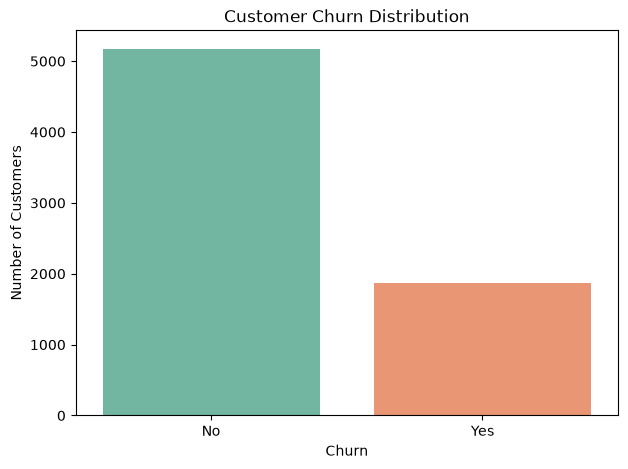

In [11]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Churn",
    hue="Churn",
    palette="Set2",
    legend=False
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

Text(0.5, 1.0, 'Customer Churn Percentage')

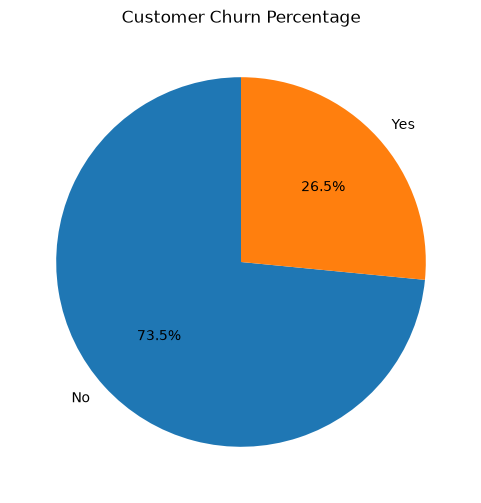

In [12]:
plt.figure(figsize=(6,6))

plt.pie(
    churn_percentage,
    labels=churn_percentage.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Customer Churn Percentage")

1. The dataset contains 7,043 customers, of which 5,174 (73.46%) remained with the company and 1,869 (26.54%) churned.

2. Approximately one out of every four customers leaves the telecom company, indicating a significant customer retention challenge.

3. The target variable exhibits a moderate class imbalance, with non-churning customers representing the majority class.

4. Due to this imbalance, relying solely on accuracy could produce misleading results. Additional evaluation metrics such as Precision, Recall, F1-Score, and ROC-AUC will be used during model evaluation.

5. The observed churn rate highlights the importance of developing an accurate churn prediction model to support proactive customer retention strategies.

### Univariate Analysis

In [13]:
# Visualization function for categorical features 

def plot_categorical_distribution(df, column):
    plt.figure(figsize=(8,5))

    order = df[column].value_counts().index

    sns.countplot(
        data=df,
        x=column,
        order=order,
        hue=column,
        palette="Set2",
        legend=False
    )

    plt.title(f"{column} Distribution")
    plt.xlabel(column)
    plt.ylabel("Count")

    plt.xticks(rotation=20)

    plt.tight_layout()

    plt.show()

    display(
        df[column]
        .value_counts()
        .to_frame("Count")
        .assign(
            Percentage=lambda x: (
                x["Count"] / len(df) * 100
            ).round(2)
        )
    )

In [14]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [15]:
categorical_features = [

    "gender",

    "SeniorCitizen",

    "Partner",

    "Dependents",

    "PhoneService",

    "MultipleLines",

    "InternetService",

    "OnlineSecurity",

    "OnlineBackup",

    "DeviceProtection",

    "TechSupport",

    "StreamingTV",

    "StreamingMovies",

    "Contract",

    "PaperlessBilling",

    "PaymentMethod"

]

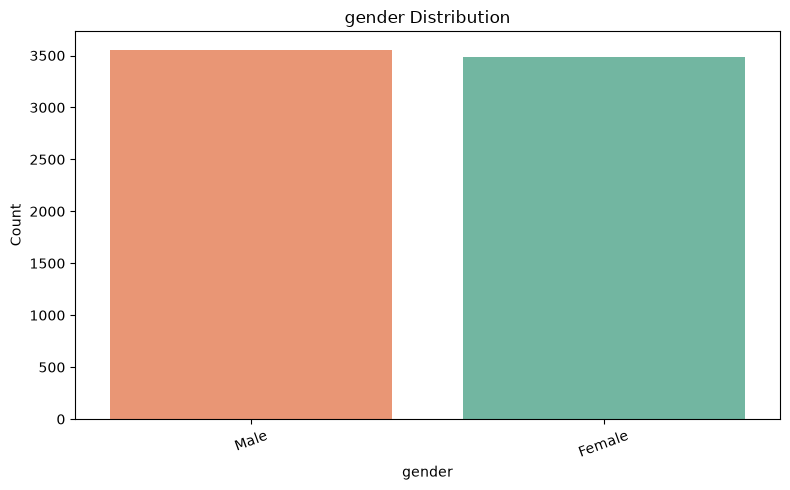

,Count,Percentage
gender,,
Male,3555,50.48
Female,3488,49.52


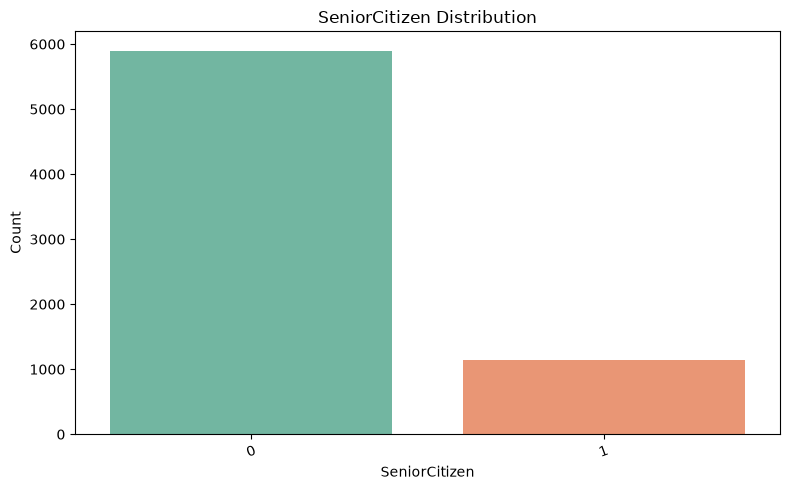

,Count,Percentage
SeniorCitizen,,
0,5901,83.79
1,1142,16.21


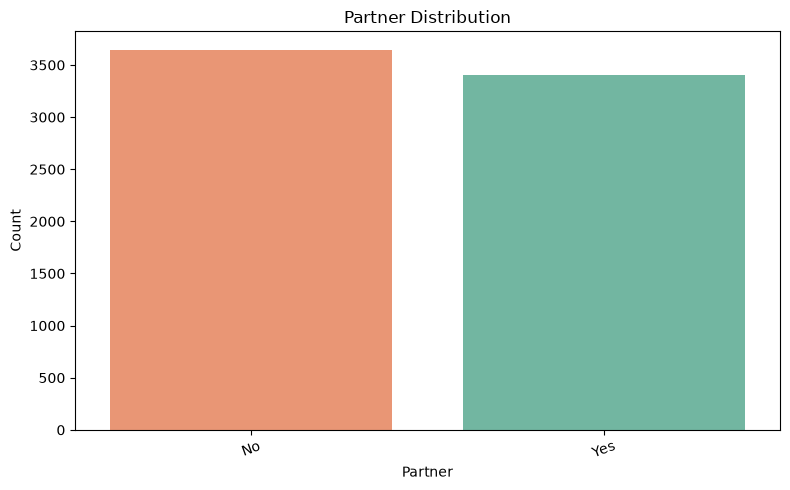

,Count,Percentage
Partner,,
No,3641,51.7
Yes,3402,48.3


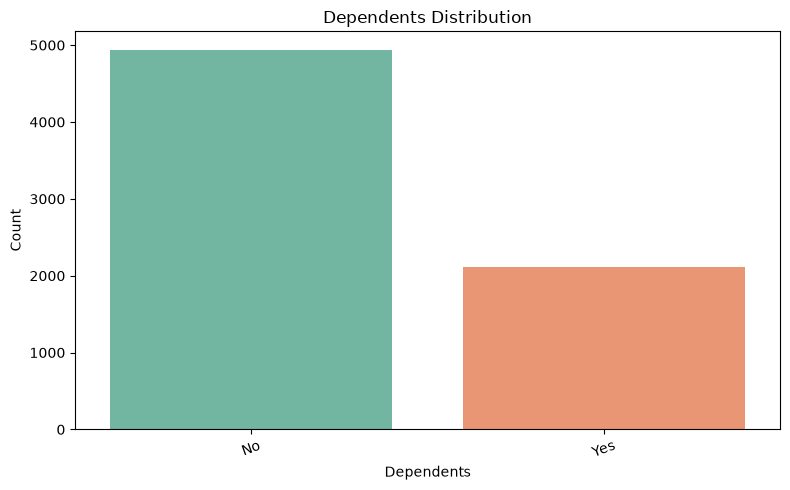

,Count,Percentage
Dependents,,
No,4933,70.04
Yes,2110,29.96


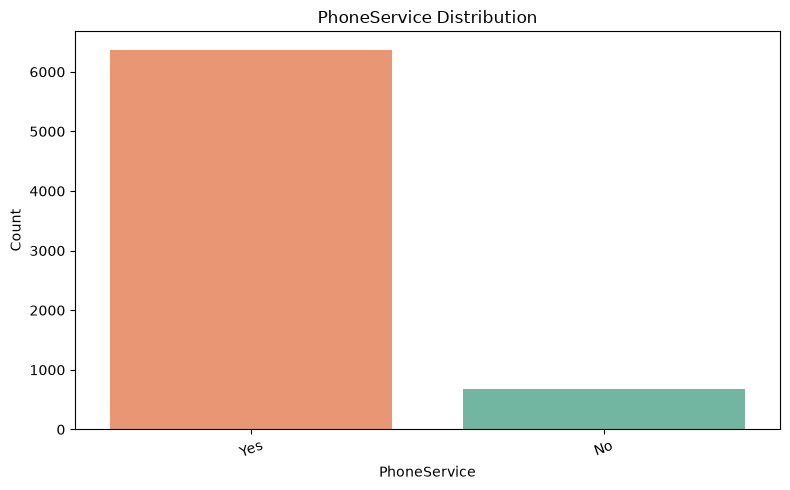

,Count,Percentage
PhoneService,,
Yes,6361,90.32
No,682,9.68


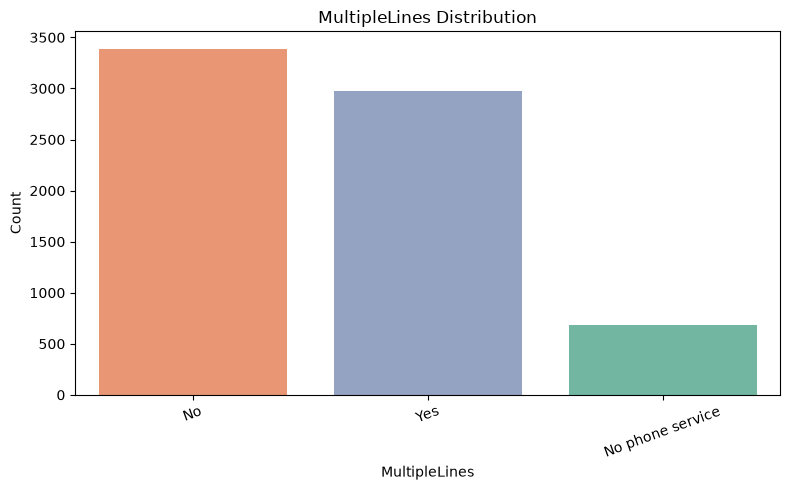

,Count,Percentage
MultipleLines,,
No,3390,48.13
Yes,2971,42.18
No phone service,682,9.68


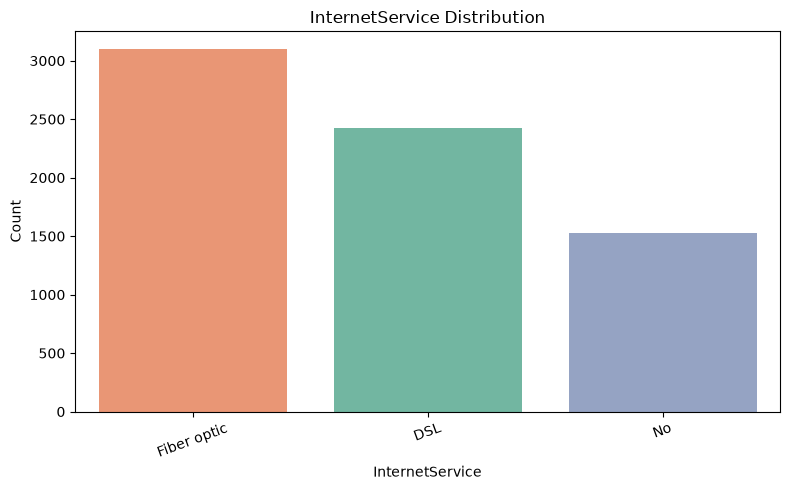

,Count,Percentage
InternetService,,
Fiber optic,3096,43.96
DSL,2421,34.37
No,1526,21.67


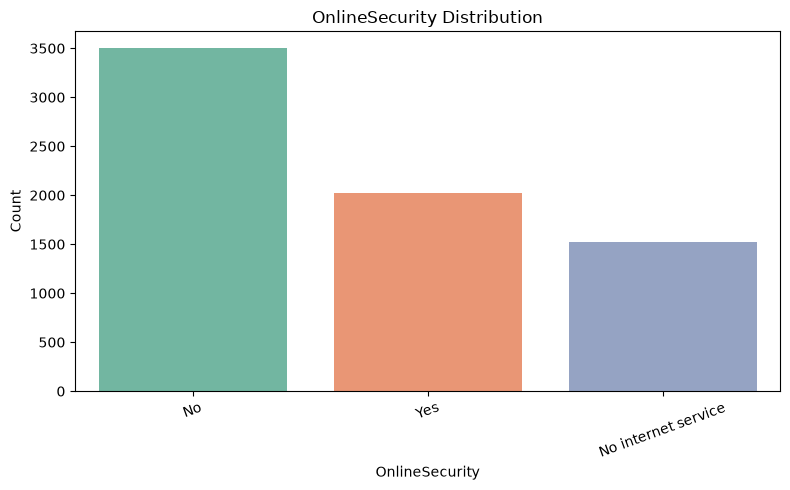

,Count,Percentage
OnlineSecurity,,
No,3498,49.67
Yes,2019,28.67
No internet service,1526,21.67


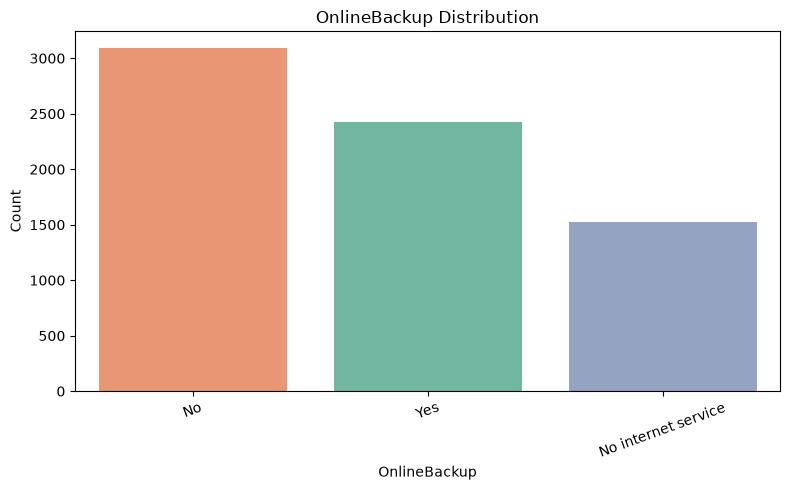

,Count,Percentage
OnlineBackup,,
No,3088,43.84
Yes,2429,34.49
No internet service,1526,21.67


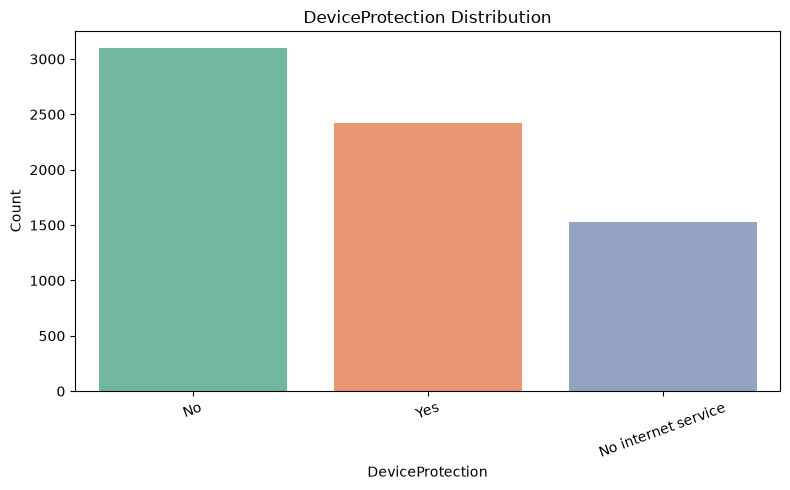

,Count,Percentage
DeviceProtection,,
No,3095,43.94
Yes,2422,34.39
No internet service,1526,21.67


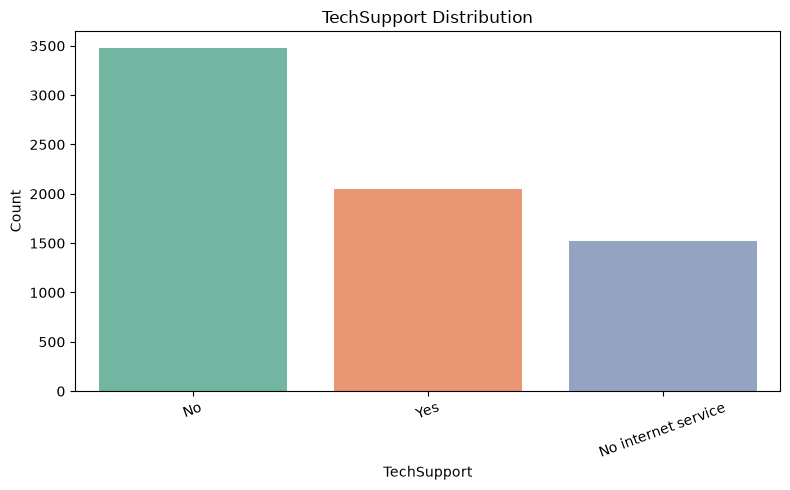

,Count,Percentage
TechSupport,,
No,3473,49.31
Yes,2044,29.02
No internet service,1526,21.67


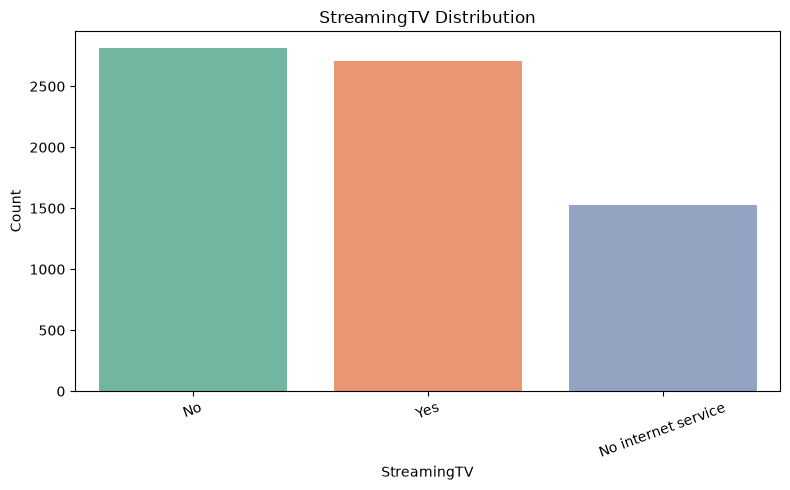

,Count,Percentage
StreamingTV,,
No,2810,39.90
Yes,2707,38.44
No internet service,1526,21.67


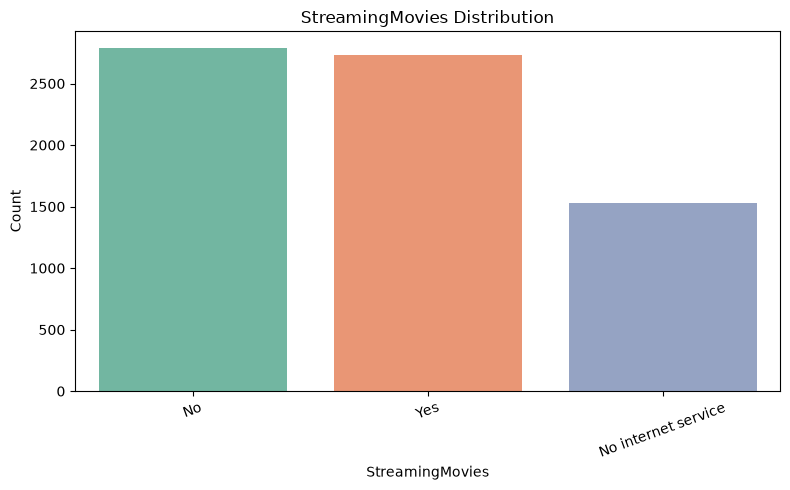

,Count,Percentage
StreamingMovies,,
No,2785,39.54
Yes,2732,38.79
No internet service,1526,21.67


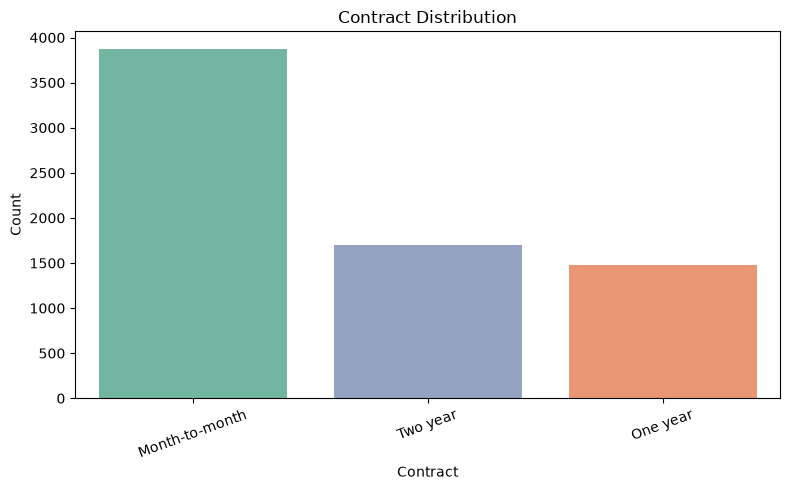

,Count,Percentage
Contract,,
Month-to-month,3875,55.02
Two year,1695,24.07
One year,1473,20.91


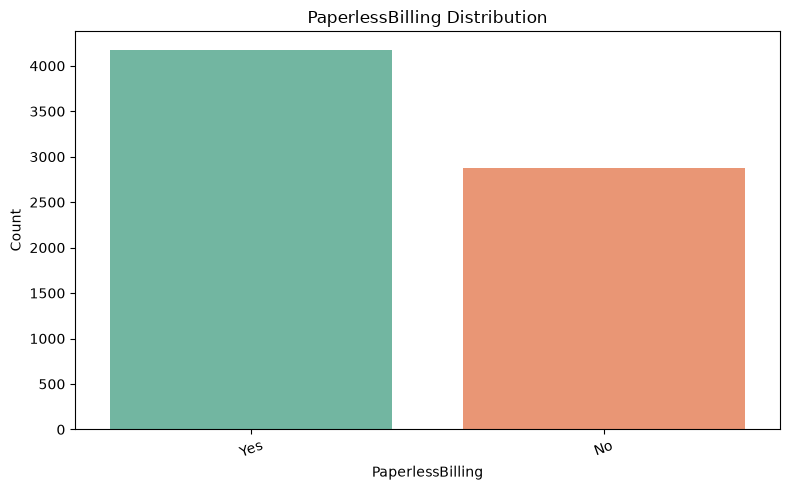

,Count,Percentage
PaperlessBilling,,
Yes,4171,59.22
No,2872,40.78


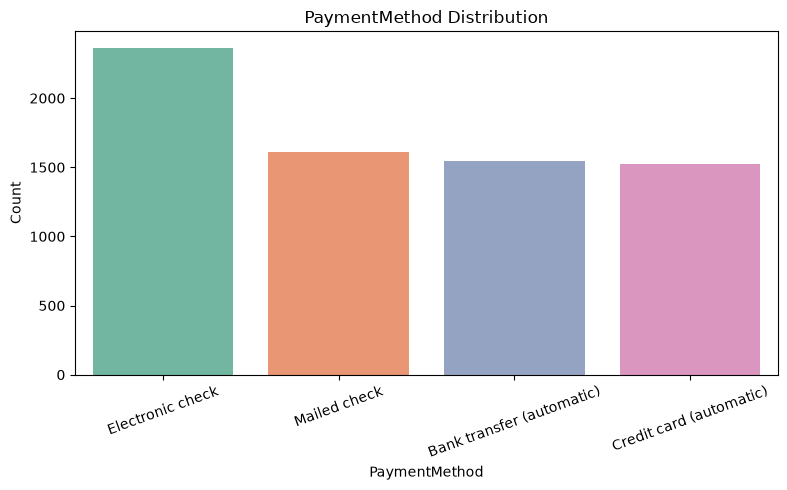

,Count,Percentage
PaymentMethod,,
Electronic check,2365,33.58
Mailed check,1612,22.89
Bank transfer (automatic),1544,21.92
Credit card (automatic),1522,21.61


In [16]:
for feature in categorical_features:
    
    plot_categorical_distribution(df, feature)

In [17]:
# Visualization function for numerical features 

def plot_numerical_distribution(df, column):

    fig, axes = plt.subplots(
        1, 
        2,
        figsize=(12,4)
    )

    sns.histplot(
        df[column],
        kde=True,
        ax=axes[0]
    )

    axes[0].set_title(f"{column} Distribution")

    sns.boxplot(
        x=df[column],
        ax=axes[1]
    )

    axes[1].set_title(f"{column} Boxplot")

    plt.tight_layout()

    plt.show()

    display(df[column].describe())

In [18]:

numerical_features = [

    "tenure",

    "MonthlyCharges"

]

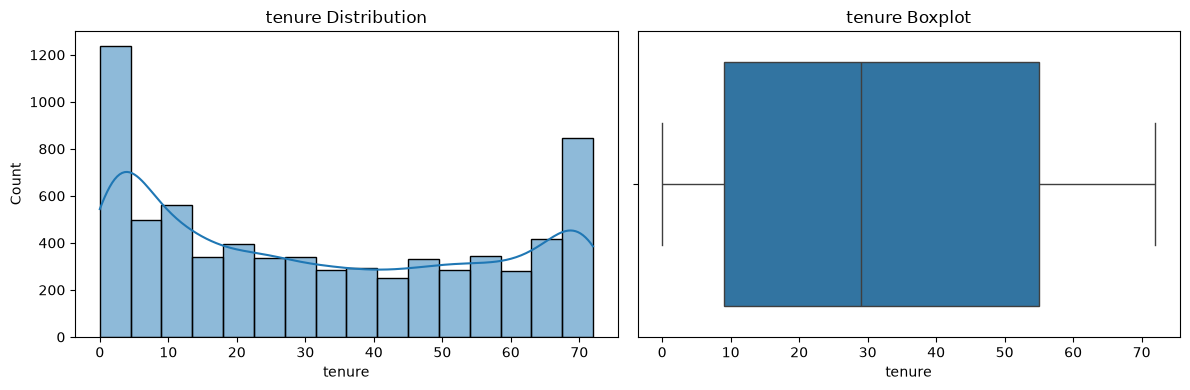

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

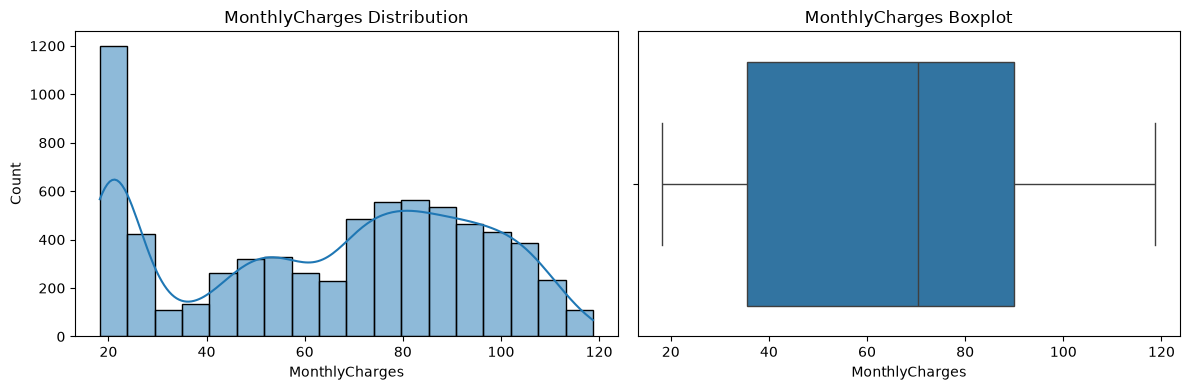

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64

In [19]:
for feature in numerical_features:

    plot_numerical_distribution(df, feature)

### Key Business Insights

1. The customer base is evenly distributed between male and female customers.

2. Most customers are non-senior citizens and do not have dependents.

3. Over 90% of customers subscribe to phone services, making it a core offering.

4. Fiber Optic is the most commonly used internet service.

5. More than half of customers are on month-to-month contracts, suggesting many customers have flexible subscription plans.

6. Electronic check is the most frequently used payment method.

7. Many customers do not subscribe to value-added services such as Online Security, Online Backup, Device Protection, and Tech Support.

8. Customer tenure exhibits a bimodal distribution, indicating a mix of new and long-term customers.

9. Monthly charges vary across multiple pricing tiers, reflecting different subscription packages.

10. Contract type, Internet Service, Payment Method, and Tenure appear to be promising features for churn prediction and will be explored further through bivariate analysis.

### Bivariate Analysis

In [20]:
# Ctegorical features vs Churn 

def plot_churn_rate(df, column):

    churn_rate = (
        pd.crosstab(
            df[column],
            df["Churn"],
            normalize="index"
        ) * 100
    )

    display(churn_rate.round(2))

    plt.figure(figsize=(8, 5))

    plt.figure(figsize=(8,5))

    churn_rate["Yes"].sort_values(
        ascending=False
    ).plot(
        kind="bar",
        color="tomato"
    )

    plt.ylabel("Churn Rate (%)")
    plt.xlabel(column)
    plt.title(f"Churn Rate by {column}") 

    plt.xticks(rotation=20)
    
    plt.show()

In [21]:
categorical_features = [

    "gender",

    "SeniorCitizen",

    "Partner",

    "Dependents",

    "PhoneService",

    "MultipleLines",

    "InternetService",

    "OnlineSecurity",

    "OnlineBackup",

    "DeviceProtection",

    "TechSupport",

    "StreamingTV",

    "StreamingMovies",

    "Contract",

    "PaperlessBilling",

    "PaymentMethod"

]

Churn,No,Yes
gender,,
Female,73.08,26.92
Male,73.84,26.16


<Figure size 800x500 with 0 Axes>

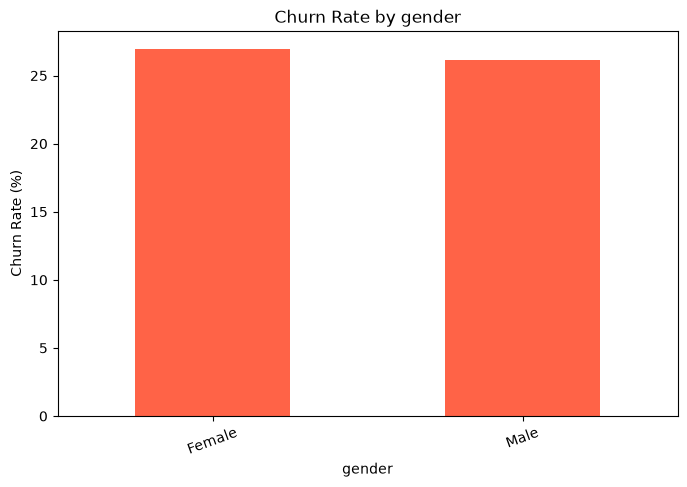

Churn,No,Yes
SeniorCitizen,,
0,76.39,23.61
1,58.32,41.68


<Figure size 800x500 with 0 Axes>

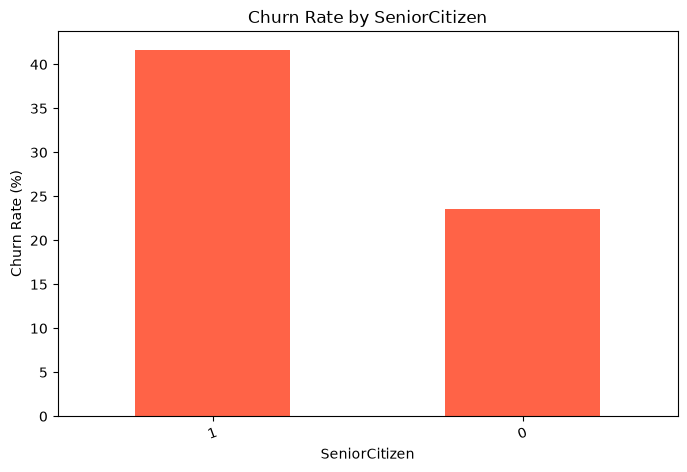

Churn,No,Yes
Partner,,
No,67.04,32.96
Yes,80.34,19.66


<Figure size 800x500 with 0 Axes>

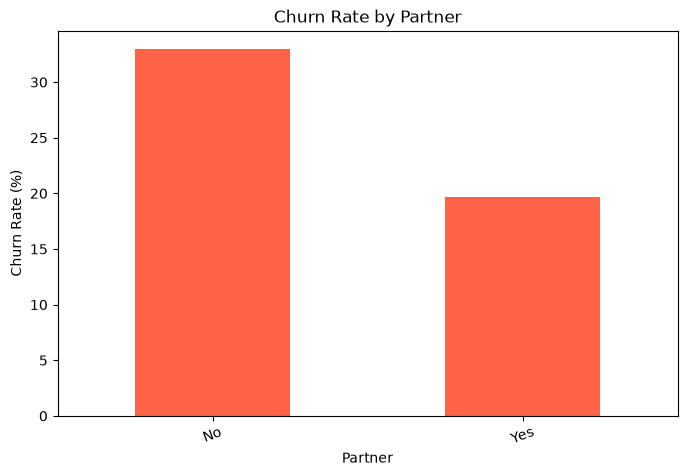

Churn,No,Yes
Dependents,,
No,68.72,31.28
Yes,84.55,15.45


<Figure size 800x500 with 0 Axes>

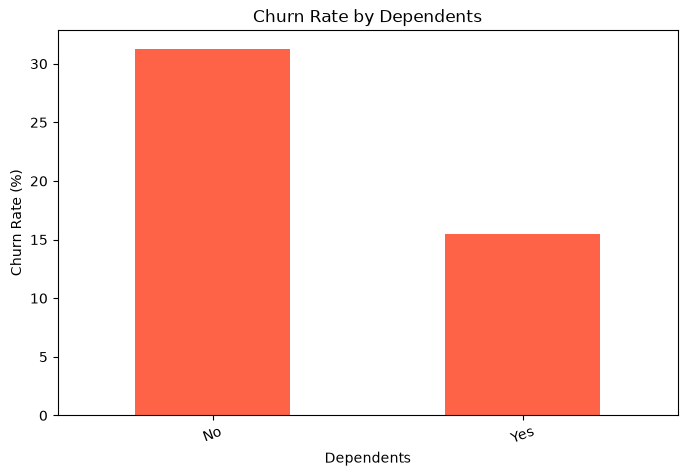

Churn,No,Yes
PhoneService,,
No,75.07,24.93
Yes,73.29,26.71


<Figure size 800x500 with 0 Axes>

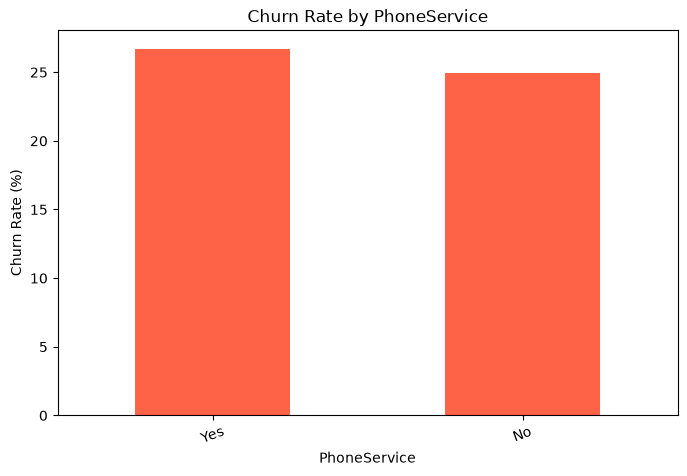

Churn,No,Yes
MultipleLines,,
No,74.96,25.04
No phone service,75.07,24.93
Yes,71.39,28.61


<Figure size 800x500 with 0 Axes>

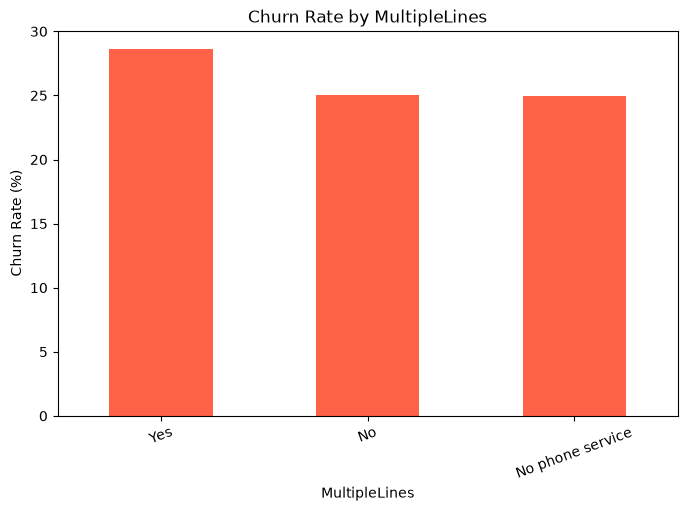

Churn,No,Yes
InternetService,,
DSL,81.04,18.96
Fiber optic,58.11,41.89
No,92.60,7.40


<Figure size 800x500 with 0 Axes>

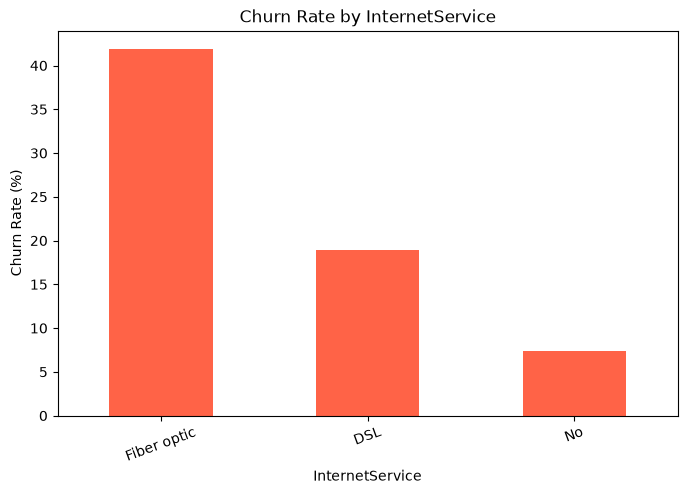

Churn,No,Yes
OnlineSecurity,,
No,58.23,41.77
No internet service,92.60,7.40
Yes,85.39,14.61


<Figure size 800x500 with 0 Axes>

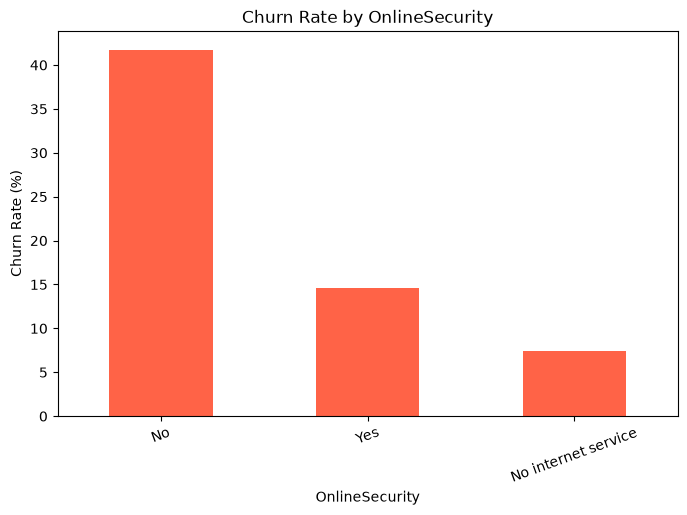

Churn,No,Yes
OnlineBackup,,
No,60.07,39.93
No internet service,92.60,7.40
Yes,78.47,21.53


<Figure size 800x500 with 0 Axes>

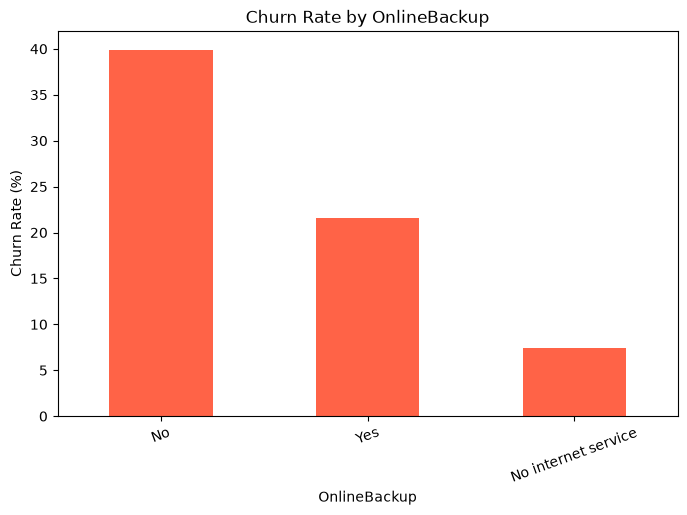

Churn,No,Yes
DeviceProtection,,
No,60.87,39.13
No internet service,92.60,7.40
Yes,77.50,22.50


<Figure size 800x500 with 0 Axes>

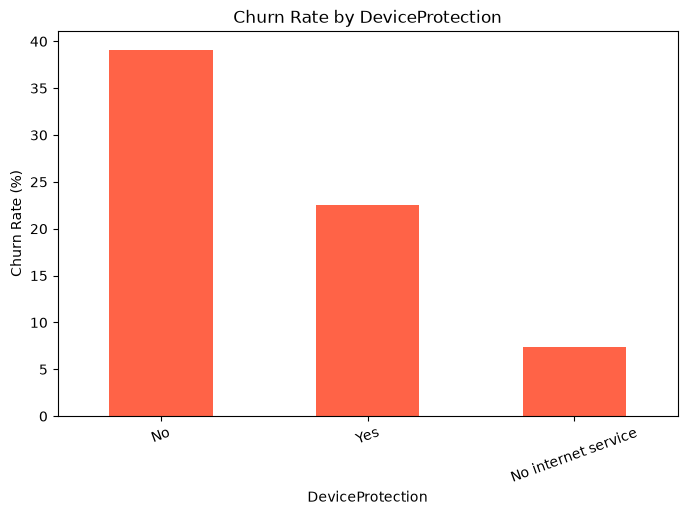

Churn,No,Yes
TechSupport,,
No,58.36,41.64
No internet service,92.60,7.40
Yes,84.83,15.17


<Figure size 800x500 with 0 Axes>

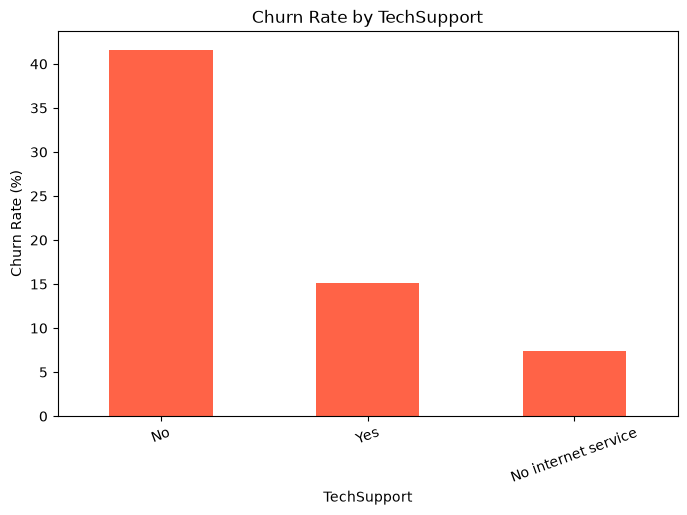

Churn,No,Yes
StreamingTV,,
No,66.48,33.52
No internet service,92.60,7.40
Yes,69.93,30.07


<Figure size 800x500 with 0 Axes>

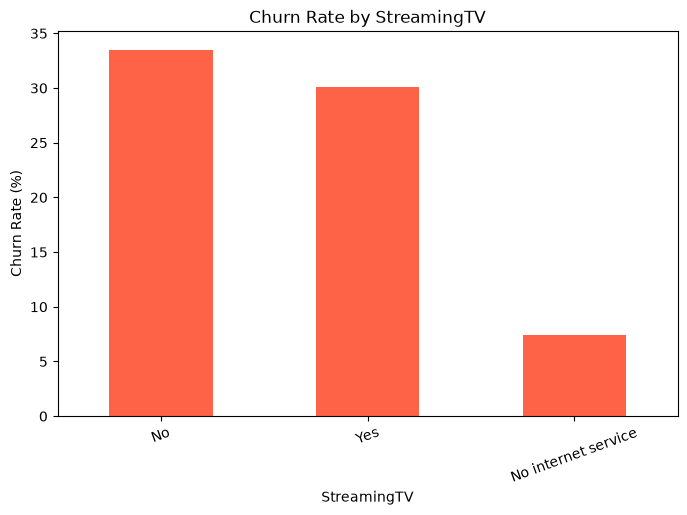

Churn,No,Yes
StreamingMovies,,
No,66.32,33.68
No internet service,92.60,7.40
Yes,70.06,29.94


<Figure size 800x500 with 0 Axes>

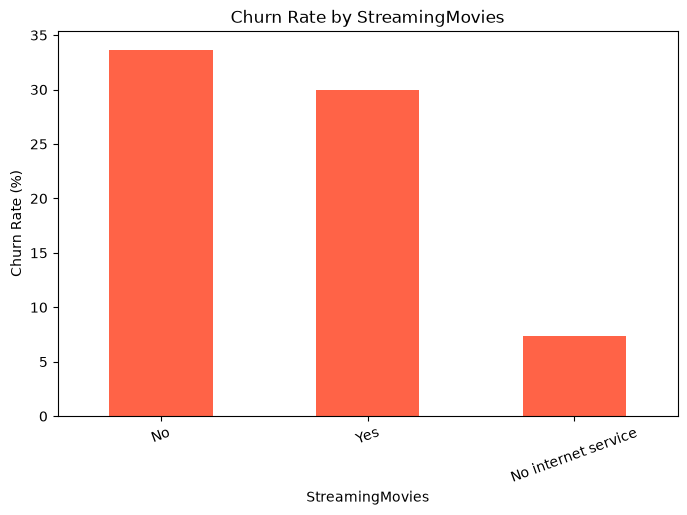

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


<Figure size 800x500 with 0 Axes>

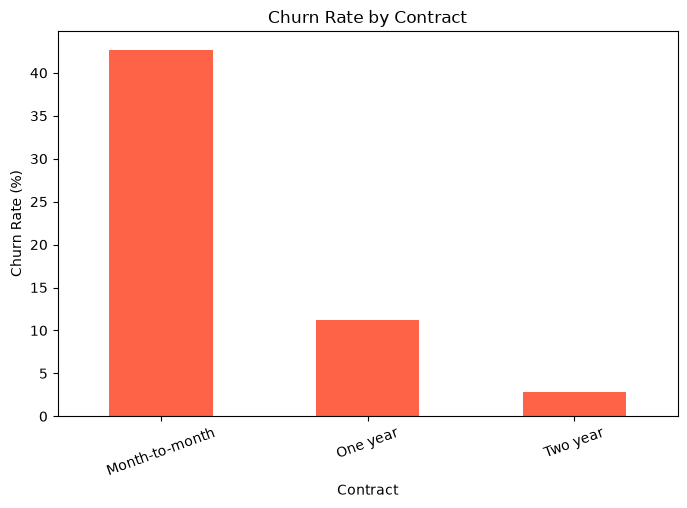

Churn,No,Yes
PaperlessBilling,,
No,83.67,16.33
Yes,66.43,33.57


<Figure size 800x500 with 0 Axes>

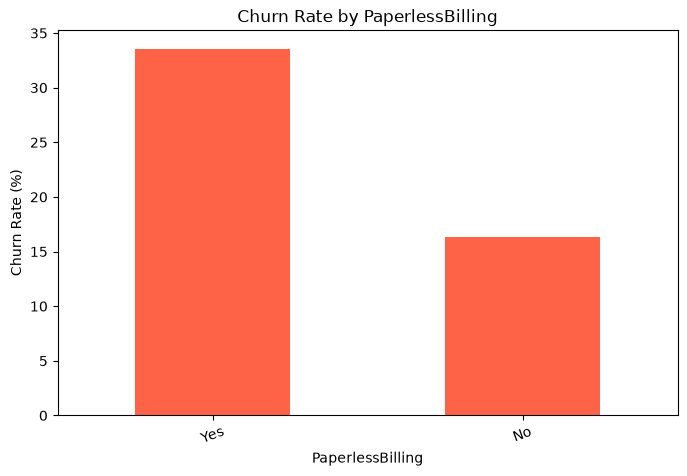

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.29,16.71
Credit card (automatic),84.76,15.24
Electronic check,54.71,45.29
Mailed check,80.89,19.11


<Figure size 800x500 with 0 Axes>

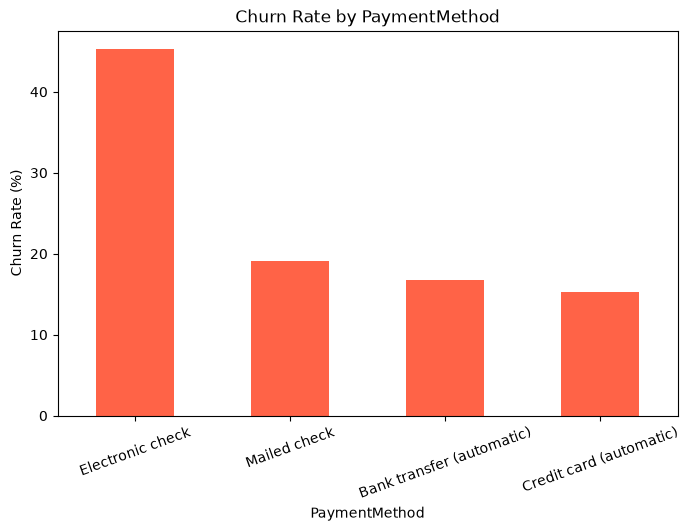

In [22]:
for feature in categorical_features:

    plot_churn_rate(df, feature)

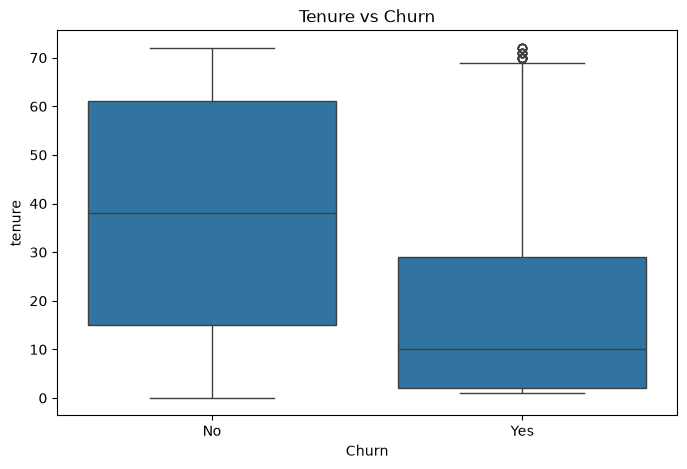

In [23]:
# Numerical Features vs Churn

# Tenure

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Tenure vs Churn")

plt.show()

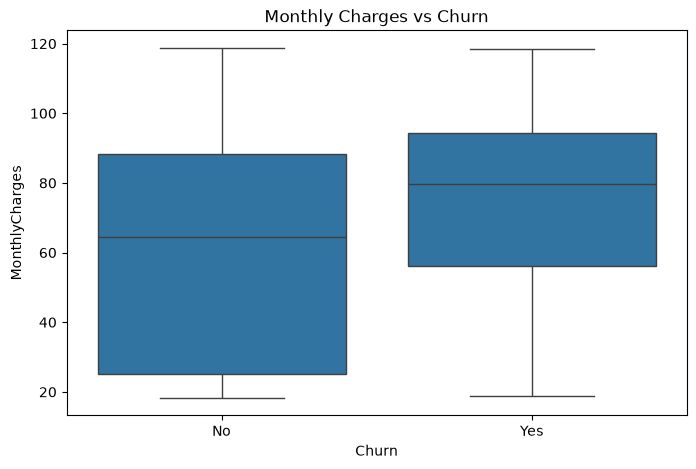

In [24]:
# Monthly Charges

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges vs Churn")

plt.show()

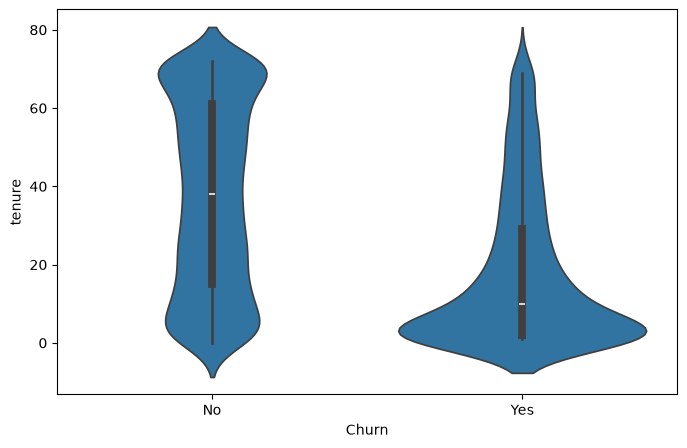

In [25]:
# Violin plots

plt.figure(figsize=(8,5))

sns.violinplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.show()

1. Conducted bivariate analysis to examine the relationship between customer features and churn.

2. Identified Contract Type and Tenure as the strongest predictors of churn.

3. Observed that Fiber Optic customers exhibit substantially higher churn rates than DSL customers.

4. Customers subscribed to Online Security, Online Backup, Device Protection, and Tech Support showed significantly lower churn rates.

5. Month-to-month contracts and Electronic Check payment methods were associated with the highest churn rates.

6. Customers with shorter tenure and higher monthly charges were more likely to churn.

7. These insights will guide feature engineering, model interpretation, and business retention strategies.

## Data Cleaning

In [26]:
df_clean = df.copy()

df_clean.shape

(7043, 21)

In [27]:
df_clean["TotalCharges"].dtype

<StringDtype(na_value=nan)>

In [28]:
(df_clean["TotalCharges"] == " ").sum()

np.int64(11)

In [29]:
# Replace Blank Spaces

df_clean["TotalCharges"] = (
    df_clean["TotalCharges"]
    .replace(" ", np.nan)
)

In [30]:
df_clean["TotalCharges"].isnull().sum()

np.int64(11)

In [31]:
# Convert to Numeric

df_clean["TotalCharges"] = pd.to_numeric(
    df_clean["TotalCharges"]
)

In [32]:
df_clean["TotalCharges"].dtype

dtype('float64')

In [33]:
df_clean[df_clean["TotalCharges"].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [34]:
df_clean.dropna(inplace=True)

In [35]:
df_clean.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [36]:
# Remove Customer ID

df_clean.drop(
    columns="customerID",
    inplace=True
)

In [37]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   str    
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   str    
 3   Dependents        7032 non-null   str    
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   str    
 6   MultipleLines     7032 non-null   str    
 7   InternetService   7032 non-null   str    
 8   OnlineSecurity    7032 non-null   str    
 9   OnlineBackup      7032 non-null   str    
 10  DeviceProtection  7032 non-null   str    
 11  TechSupport       7032 non-null   str    
 12  StreamingTV       7032 non-null   str    
 13  StreamingMovies   7032 non-null   str    
 14  Contract          7032 non-null   str    
 15  PaperlessBilling  7032 non-null   str    
 16  PaymentMethod     7032 non-null   str    
 17  MonthlyChar

In [38]:
df_clean.shape

(7032, 20)

1. Created a working copy of the original dataset to preserve the raw data.

2. Identified hidden missing values in the `TotalCharges` column represented by blank strings.

3. Replaced blank strings with `NaN` and converted `TotalCharges` to a numeric data type.

4. Investigated the missing records and observed that all belonged to new customers with zero tenure.

5. Removed the 11 incomplete records, representing only 0.16% of the dataset, to avoid introducing artificial values.

6. Dropped the `customerID` column because it is a unique identifier with no predictive value.

7. Verified that the cleaned dataset contains 7,032 records, 20 features, no missing values, and correct data types, making it ready for feature engineering.

### Binary Encoding

In [39]:
df_clean.nunique()

gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                72
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1584
TotalCharges        6530
Churn                  2
dtype: int64

In [40]:
df_encoded = df_clean.copy()

In [41]:
binary_columns = [

    "gender",

    "Partner",

    "Dependents",

    "PhoneService",

    "PaperlessBilling"

]

In [42]:
for col in binary_columns:
    print(f"{col}: {df_encoded[col].unique()}")

gender: <ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str
Partner: <ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str
Dependents: <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
PhoneService: <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
PaperlessBilling: <ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str


In [43]:
binary_mapping = {

    "Yes": 1,
    "No": 0,

    "Male": 1,
    "Female": 0

}

In [44]:
for col in binary_columns:
    df_encoded[col] = df_encoded[col].map(binary_mapping)

In [45]:
df_encoded[binary_columns].head()

,gender,Partner,Dependents,PhoneService,PaperlessBilling
0,0,1,0,0,1
1,1,0,0,1,0
2,1,0,0,1,1
3,1,0,0,0,0
4,0,0,0,1,1


In [46]:
df_encoded[binary_columns].dtypes

gender              int64
Partner             int64
Dependents          int64
PhoneService        int64
PaperlessBilling    int64
dtype: object

1. Identified binary categorical features with exactly two unique values.

2. Excluded `SeniorCitizen` because it was already represented numerically.

3. Encoded binary features using explicit dictionary mapping:
   - Yes → 1
   - No → 0
   - Male → 1
   - Female → 0

4. Used the `.map()` function instead of automated encoders to maintain clarity and control over the encoding process.

5. Verified that all binary features were successfully converted to integer data types and are now suitable for machine learning models.